# 1. Matrix inverse and pseudoinverse

You can now multiply and transpose matrices. This lesson asks whether a multiplication can be undone. You will distinguish an exact inverse from a least-squares pseudoinverse, solve a two-variable system by hand, and investigate why small measurement errors can produce large changes in a solution. Prerequisites: [matrix multiplication](../../../02_Mathematics_for_ML/10_matrix_multiplication.ipynb) and [transpose](../../../02_Mathematics_for_ML/11_matrix_transpose.ipynb). All numbers here are dimensionless synthetic measurements; no external dataset is needed.

## 2. What problem does this solve?

Suppose two instruments combine two unknown quantities into two recorded measurements. Knowing the mixing rule, can we recover the unknown quantities? Sometimes yes. Sometimes the instruments record the same information twice, so several inputs produce the same measurements. Sometimes more measurements are recorded than there are unknowns, and noise makes exact agreement impossible. These are different problems and need different interpretations of an answer.

## 3. Intuition before mathematics

An inverse is like undoing a reversible recipe: if the original ingredients leave distinct traces, you can reconstruct their amounts. A recipe that discards information cannot be reversed uniquely. Adding two quantities and keeping only the total loses their individual values. A pseudoinverse provides a particular best-fit answer; it does not magically recover discarded information. Think of placing a ruler through the origin and finding the closest point on it to a measured point.

## 4. Terminology

A square matrix has the same number of rows and columns. An invertible square matrix has one inverse, a matrix that reverses its action. The identity matrix leaves a vector unchanged. A singular matrix has no inverse. A residual is observed minus reconstructed output. Least squares minimizes the sum of squared residual components. The pseudoinverse, written with a superscript plus, exists even for rectangular and singular matrices. When multiple least-squares solutions exist, it selects the one with smallest Euclidean length.

## 5. Mathematical foundations

For a square matrix \(A\) of shape \((n,n)\), its inverse \(A^{-1}\) satisfies
\[
A^{-1}A=AA^{-1}=I_n,\qquad Ax=b\Rightarrow x=A^{-1}b.
\]
Here \(n\) counts unknowns, \(I_n\) is the identity, \(x\) is an unknown length-\(n\) vector, and \(b\) contains measured outputs. The superscript minus one means inverse, not taking the reciprocal of every entry.

For \(A=\begin{bmatrix}a&b\\c&d\end{bmatrix}\), define the determinant \(D=ad-bc\). If \(D\ne0\),
\[
A^{-1}=\frac1D\begin{bmatrix}d&-b\\-c&a\end{bmatrix}.
\]
The letters in this small formula are scalar entries; its \(b\) is not the measurement vector above. The determinant measures signed area scaling: zero means a square has been flattened and information lost.

For a nonzero single-column matrix \(u\) of shape \((m,1)\),
\[
u^+=\frac{u^T}{u^Tu},\quad \hat x=u^+y,\quad r=y-u\hat x.
\]
The transpose \(u^T\) has shape \((1,m)\); \(u^Tu\) is a positive scalar. Observations \(y\) have length \(m\), the estimated coefficient \(\hat x\) is scalar, and the residual \(r\) has length \(m\). This minimizes \(\sum_{i=1}^m r_i^2\), with \(i\) indexing measurements. This special formula is not a general pseudoinverse implementation.

## 6. Hand-calculated example

Take \(A=[[2,1],[1,1]]\). Its determinant is \(2(1)-1(1)=1\), so the inverse is \([[1,-1],[-1,2]]\). Input \([3,2]\) produces \([8,5]\). Reversing gives \([8-5,-8+10]=[3,2]\). Direct multiplication of inverse and original gives diagonal entries one and off-diagonal entries zero.

For \(u=[1,2]^T\) and \(y=[1,3]\), the denominator is \(1^2+2^2=5\), numerator \(1(1)+2(3)=7\), and coefficient \(7/5=1.4\). Predicted measurements are \([1.4,2.8]\); residuals are \([-0.4,0.2]\). Their squared sum is \(0.16+0.04=0.20\). Notice \(1(-0.4)+2(0.2)=0\): the residual is perpendicular to the direction we can represent.

## 7. Implementation from scratch

The function below accepts only a finite two-by-two matrix. `raise` reports invalid input immediately. Unpacking assigns four entries to named scalars; a floating-point tolerance rejects small determinants. That tolerance is a teaching safeguard with a scale-dependent meaning, not a robust general test of invertibility.

In [1]:
# Enable embedded figures in this fresh notebook kernel.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

In [2]:
import numpy as np

def inverse_two_by_two(values, tolerance=1e-12):
    matrix = np.asarray(values, dtype=float)
    if matrix.shape != (2, 2) or not np.isfinite(matrix).all():
        raise ValueError('Provide a finite 2 by 2 matrix.')
    if not np.isfinite(tolerance) or tolerance < 0:
        raise ValueError('Tolerance must be finite and nonnegative.')
    a, b, c, d = matrix.ravel()
    determinant = a*d - b*c
    if abs(determinant) <= tolerance:
        raise ValueError('Determinant is too small for this teaching formula.')
    return np.array([[d, -b], [-c, a]]) / determinant

A = np.array([[2., 1.], [1., 1.]])
inverse = inverse_two_by_two(A)
assert np.allclose(inverse, [[1, -1], [-1, 2]])
assert np.allclose(inverse @ A, np.eye(2))
assert np.allclose(A @ inverse, np.eye(2))
print('Inverse:', inverse)

Inverse: [[ 1. -1.]
 [-1.  2.]]


## 8. Step-by-step output inspection

Multiplication by the inverse reconstructs the original input. The single-column calculation separately shows what happens when two equations disagree about one coefficient. `@` is matrix multiplication; dividing a row vector by a scalar divides each entry.

In [3]:
x = np.array([3., 2.])
b = A @ x
print('Input, measured output, recovered input:', x, b, inverse @ b)
u = np.array([1., 2.])
y = np.array([1., 3.])
u_plus = u / (u @ u)
coefficient = u_plus @ y
prediction = u * coefficient
residual = y - prediction
assert np.isclose(coefficient, 1.4)
assert np.allclose(residual, [-.4, .2])
assert np.isclose(u @ residual, 0)
print('Coefficient, prediction, residual:', coefficient, prediction, residual)

Input, measured output, recovered input: [3. 2.] [8. 5.] [3. 2.]
Coefficient, prediction, residual: 1.4000000000000001 [1.4 2.8] [-0.4  0.2]


## 9. Library implementation

Use `np.linalg.solve(A, b)` for a nonsingular square system. It solves directly rather than explicitly building an inverse. Use `np.linalg.lstsq` when the goal is a least-squares solution, or `np.linalg.pinv` when the pseudoinverse itself is needed. NumPy uses numerical matrix factorizations; later singular-value decomposition explains the general pseudoinverse mechanism. `rcond=None` asks least squares to use its default numerical cutoff.

In [4]:
assert np.allclose(np.linalg.solve(A, b), x)
column = u[:, None]  # None adds a column axis: shape (2, 1).
library_coefficient = np.linalg.lstsq(column, y, rcond=None)[0]
assert np.allclose(library_coefficient, [1.4])
assert np.allclose(np.linalg.pinv(column), u_plus[None, :])
singular = np.array([[1., 2.], [2., 4.]])
try:
    np.linalg.inv(singular)
except np.linalg.LinAlgError:
    print('Exactly singular example correctly rejected.')
else:
    raise AssertionError('Expected singular-matrix rejection.')

Exactly singular example correctly rejected.


## 10. Visualization

The orange point is the closest representable measurement to the blue observation. The dotted residual joins them perpendicular to the line. The origin is required here because our one-column model has no intercept. A model with an intercept would describe a different family of possible predictions.

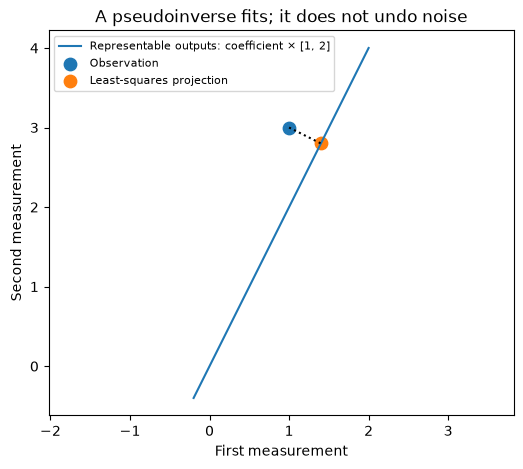

In [5]:
import matplotlib.pyplot as plt
from IPython.display import display
fig, ax = plt.subplots(figsize=(6, 5))
t = np.linspace(-.2, 2, 100)
ax.plot(t, 2*t, label='Representable outputs: coefficient × [1, 2]')
ax.scatter(*y, label='Observation', s=80)
ax.scatter(*prediction, label='Least-squares projection', s=80)
ax.plot([y[0], prediction[0]], [y[1], prediction[1]], 'k:')
ax.set(xlabel='First measurement', ylabel='Second measurement',
       title='A pseudoinverse fits; it does not undo noise')
ax.axis('equal')
ax.legend(fontsize=8)
display(fig)
plt.close(fig)

## 11. Realistic synthetic experiment

Imagine nearly redundant sensors. Their mixing matrix is almost singular. A one-millionth measurement perturbation changes recovered inputs by about one whole unit. A tiny reconstruction residual therefore does not establish reliable recovery. This is a controlled sensitivity demonstration, not a claim about all sensors.

In [6]:
epsilon = 1e-6
sensor = np.array([[1., 1.], [1., 1. + epsilon]])
truth = np.array([1., 1.])
measurement = sensor @ truth
changed = measurement + np.array([0., epsilon])
first = np.linalg.solve(sensor, measurement)
second = np.linalg.solve(sensor, changed)
assert np.allclose(first, [1, 1])
assert np.allclose(second, [0, 2], atol=1e-8)
print('Original and perturbed recovery:', first, second)
print('Measurement change:', changed - measurement)

Original and perturbed recovery: [1. 1.] [-4.4408921e-10  2.0000000e+00]
Measurement change: [0.e+00 1.e-06]


## 12. Configuration and learned quantities

There is no iterative training algorithm in exact inversion. Matrix entries are supplied. In the least-squares example, the coefficient is estimated from observations; prediction then multiplies a new supplied row by that coefficient. Numerical cutoffs are computational choices, not learned weights. Too aggressive a cutoff discards meaningful directions; too permissive a cutoff can amplify noise. Regularization, studied later, deliberately changes the estimation objective rather than merely choosing a numerical implementation.

## 13. Evaluation

Check both identity products for a proposed inverse and the residual for a solve. For least squares, check that the residual is perpendicular to represented directions, within floating-point tolerance. Also inspect sensitivity to realistic measurement changes. An exact algebraic solution may have poor scientific accuracy when inputs are noisy. These tests concern supplied systems; evaluating a predictive model would additionally require observations excluded from coefficient fitting.

## 14. Assumptions and limitations

Square shape alone does not imply invertibility. Our hand formula does not handle larger matrices and can overflow or lose precision with extreme entries. Pseudoinverse fitting assumes squared discrepancies are a meaningful objective. If sensor errors differ greatly in scale, unweighted squared errors may be inappropriate. We have not inferred uncertainty or identified which measurements are trustworthy.

## 15. Common mistakes and debugging

Do not replace inverse with `1 / A`: that is elementwise reciprocal. Do not force a square system by deleting observations without justification. A zero residual with a singular matrix does not establish unique coefficients. Inspect shape, repeated rows or columns, and numerical scale before blaming the library. A determinant cutoff depends on units and size, so it is a poor universal diagnostic.

## 16. Comparison with alternatives

Direct solve is appropriate for a well-posed square system. Least squares handles incompatible equations. A pseudoinverse additionally defines a minimum-length answer when solutions are not unique. Regularized regression can stabilize noisy estimation by imposing a penalty. More measurements only help identify unknowns when they add useful information; the next lesson calls this independent information rank.

## 17. Exercises

1. **Beginner:** Recover an input from output [5, 3] using our matrix.
2. **Beginner:** Explain why [[1, 2], [2, 4]] cannot have an inverse.
3. **Beginner:** Find the single-column coefficient for u=[1, 2], y=[2, 4].
4. **Intermediate:** Compare solutions [0, 2] and [1, 1] to x1+x2=2. Which has smaller length?
5. **Intermediate:** Change the sensor perturbation to half epsilon and predict the recovered inputs before running code.
6. **Challenge:** Prove the coefficient formula minimizes squared residuals without calculus, by completing a square around 1.4.

## 18. Detailed solutions

1. The inverse gives [5-3, -5+6]=[2, 1].
2. Its second row is twice its first; both equations record the same constraint. Inputs [2, 0] and [0, 1] both yield [2, 4].
3. The numerator is 10 and denominator 5, so coefficient 2 reproduces both measurements exactly.
4. Both sums equal 2, but squared lengths are 4 and 2. Their lengths are 2 and the square root of 2. The pseudoinverse chooses [1, 1].
5. The second equation minus the first gives epsilon times x2 equal to 1.5 epsilon. Therefore x2=1.5 and x1=.5.
6. For coefficient c, squared error is (1-c)^2+(3-2c)^2=5c^2-14c+10=5(c-1.4)^2+.2. The square cannot be negative, so c=1.4 is the unique minimum. This is the essential fitting argument, independent of any library call.

In [7]:
assert np.allclose(inverse @ [5, 3], [2, 1])
assert np.isclose(u_plus @ [2, 4], 2)
assert np.allclose(np.linalg.pinv([[1., 1.]]) @ [2.], [1, 1])
assert np.allclose(np.linalg.solve(sensor, measurement + [0, epsilon/2]), [.5, 1.5])
for c in [-2., 0., 1.4, 3.]:
    assert np.isclose(np.sum((y - c*u)**2), 5*(c-1.4)**2 + .2)

## 19. Knowledge check

**Does every square matrix have an inverse?** No; distinct inputs must produce distinct outputs.

**What does identity multiplication do?** It preserves all vector coordinates.

**Can a rectangular matrix have a pseudoinverse?** Yes; its shape is reversed.

**Must a least-squares residual be zero?** No; incompatible observations cannot all be reproduced.

**Does a small residual guarantee stable recovery?** No; nearly redundant measurements can amplify tiny errors.

## 20. Interview preparation

**Why prefer solve over explicitly forming an inverse?** It computes the requested solution directly and avoids unnecessary inverse construction.

**What does the pseudoinverse choose among multiple solutions?** The least-squares solution with minimum Euclidean length.

**What is the geometry of least squares?** Projection onto the space of outputs the matrix can represent.

**Why can redundant features cause trouble?** Different coefficient combinations may generate identical predictions, making individual coefficients unidentifiable.

**Is the two-by-two formula a production solver?** No; general stable solvers use matrix factorizations and numerical safeguards beyond this lesson.

## 21. Summary and next steps

An inverse reverses an information-preserving square transformation. A pseudoinverse solves a best-fit problem with a minimum-length convention when necessary. Neither restores information that measurements never contained. Continue to [rank](../../../02_Mathematics_for_ML/13_rank.ipynb) to count independent directions explicitly.